# Support Vector Machine (SVM) Classification
## Machine Learning Applications in Finance - FINA 455

### Methodology
- **Dataset split**: 80% training, 20% testing
- **Same random seed** used across all models
- **Hyperparameters** (C and gamma) selected using cross-validation on the training set
- **Final evaluation** performed only on the test set

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [ ]:
# Load the dataset from Excel file
df = pd.read_excel("Project Database.xlsx")
df.columns = df.columns.str.strip()

# Define target variable
target = "Personal.Loan"

# Define dependent and independent variables
Y = df[target]
X = df.drop(columns=[target, "City"])  # Drop City as instructed

# Convert categorical columns to dummies
X = pd.get_dummies(X, drop_first=True)

# Combine and drop missing values
data = pd.concat([Y, X], axis=1).dropna()

Y = data[target]
X = data.drop(columns=[target])

# Force everything to numeric
X = X.apply(pd.to_numeric, errors="coerce")
Y = pd.to_numeric(Y, errors="coerce")

# Drop rows made missing by coercion
data = pd.concat([Y, X], axis=1).dropna()
Y = data[target]
X = data.drop(columns=[target])

X = X.astype(float)
Y = Y.astype(float)

# Display dataset information
print("Dataset loaded.")
print(f"Total samples: {len(Y)}")
print(f"Features: {X.shape[1]}")
print(f"Target distribution: {Y.value_counts().to_dict()}")

Dataset loaded successfully!
Total samples: 5000
Features: 12
Target distribution:
Personal.Loan
0.0    4520
1.0     480
Name: count, dtype: int64

Feature names:
['Age', 'Experience', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities.Account', 'CD.Account', 'Online', 'CreditCard', 'Median Income Per City', 'Income / Median in city']


In [7]:
# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=Y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")
print(f"Train class 0: {sum(y_train == 0)}")
print(f"Train class 1: {sum(y_train == 1)}")
print(f"Test class 0: {sum(y_test == 0)}")
print(f"Test class 1: {sum(y_test == 1)}")

Train size: 4000
Test size: 1000
Train class 0: 3616
Train class 1: 384
Test class 0: 904
Test class 1: 96


In [ ]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization done.")

Standardization completed successfully

Training data shape: (4000, 12)
Test data shape: (1000, 12)

Scaled training data - Mean: [-0. -0.  0.  0.  0.  0.  0.  0.  0.  0. -0. -0.]
Scaled training data - Std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [8]:
# SVM hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

svm_base = SVC(kernel='rbf', probability=True, random_state=42)

grid_search = GridSearchCV(
    svm_base, 
    param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_C = grid_search.best_params_['C']
best_gamma = grid_search.best_params_['gamma']

print(f"Best C: {best_C}")
print(f"Best gamma: {best_gamma}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best C: 10
Best gamma: 0.1


In [ ]:
# Show GridSearchCV results
results_df = pd.DataFrame(grid_search.cv_results_)
results_summary = results_df[['param_C', 'param_gamma', 'mean_test_score', 'std_test_score']].copy()
results_summary.columns = ['C', 'gamma', 'Mean CV Score', 'Std CV Score']
results_summary = results_summary.sort_values('Mean CV Score', ascending=False)

print(results_summary.to_string(index=False))


All GridSearchCV Results (sorted by accuracy):
    C  gamma  Mean CV Accuracy  Std CV Accuracy
 10.0  0.100           0.97100         0.003824
100.0  0.010           0.97100         0.006442
 10.0  0.010           0.96425         0.005948
100.0  0.100           0.96325         0.004717
  1.0  0.100           0.96275         0.004287
100.0  0.001           0.95700         0.002574
  1.0  0.010           0.94950         0.002693
 10.0  0.001           0.93975         0.000500
 10.0  1.000           0.91325         0.002574
100.0  1.000           0.91325         0.002574
  1.0  0.001           0.90950         0.002318
  0.1  0.100           0.90875         0.001936
  1.0  1.000           0.90775         0.002424
  0.1  0.010           0.90500         0.000000
  0.1  0.001           0.90400         0.000500
  0.1  1.000           0.90400         0.000500


In [10]:
# Get the best estimator from GridSearchCV
best_svm = grid_search.best_estimator_

# Make predictions on test set
y_pred_proba = best_svm.predict_proba(X_test_scaled)[:, 1]
y_pred = best_svm.predict(X_test_scaled)


print(f"Predicted classes: {np.unique(y_pred)}")
unique, counts = np.unique(y_pred, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count}")

Predicted classes: [0. 1.]
Class 0.0: 912
Class 1.0: 88


In [11]:
# Calculate all evaluation metrics
test_mse = np.mean((y_pred - y_test) ** 2)
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
test_cm = confusion_matrix(y_test, y_pred)

print(f"MSE: {test_mse:.6f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1: {test_f1:.4f}")
print(f"ROC AUC: {test_roc_auc:.4f}")
print(f"Confusion matrix:\n{test_cm}")
print(classification_report(y_test, y_pred, target_names=['No Loan', 'Loan']))

MSE: 0.024000
Accuracy: 0.9760
Precision: 0.9091
Recall: 0.8333
F1: 0.8696
ROC AUC: 0.9885
Confusion matrix:
[[896   8]
 [ 16  80]]
              precision    recall  f1-score   support

     No Loan       0.98      0.99      0.99       904
        Loan       0.91      0.83      0.87        96

    accuracy                           0.98      1000
   macro avg       0.95      0.91      0.93      1000
weighted avg       0.98      0.98      0.98      1000



In [13]:
# Summary statistics
print(f"Test set size: {len(y_test)}")
print(f"Train set size: {len(y_train)}")
print(f"Best C: {best_C}")
print(f"Best gamma: {best_gamma}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1: {test_f1:.4f}")
print(f"ROC AUC: {test_roc_auc:.4f}")
print(f"Support vectors: {len(best_svm.support_vectors_)}")

Test set size: 1000
Train set size: 4000
Best C: 10
Best gamma: 0.1
Accuracy: 0.9760
Precision: 0.9091
Recall: 0.8333
F1: 0.8696
ROC AUC: 0.9885
Support vectors: 469


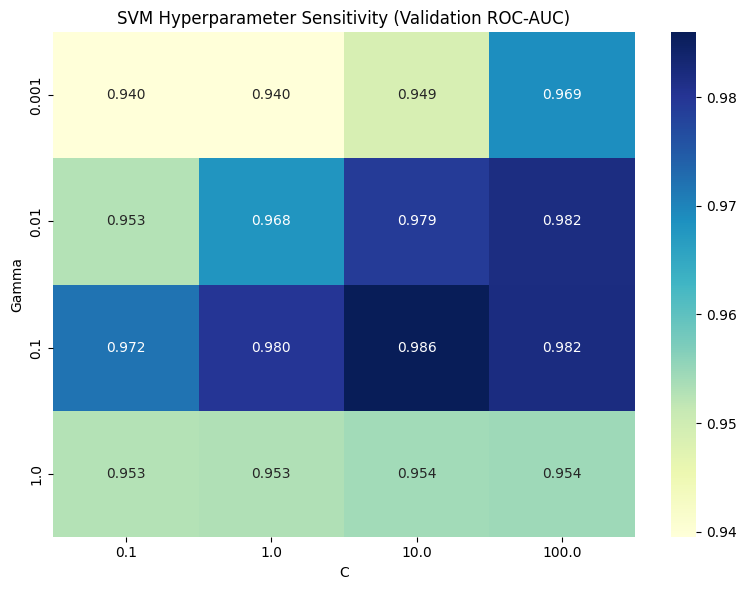

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.DataFrame(grid_search.cv_results_)

pivot = results.pivot(index="param_gamma", columns="param_C", values="mean_test_score")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("SVM Hyperparameter Sensitivity (Validation ROC-AUC)")
plt.xlabel("C")
plt.ylabel("Gamma")
plt.tight_layout()
plt.show()

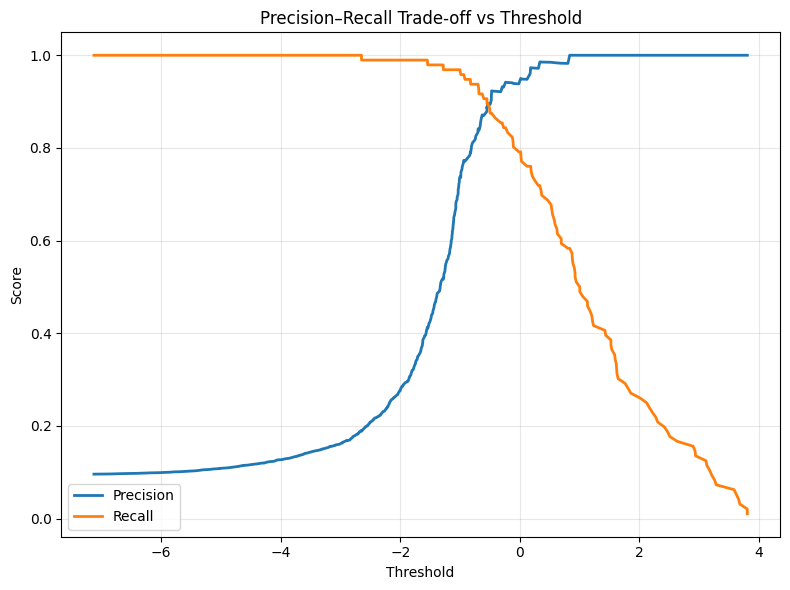

In [ ]:
from sklearn.metrics import precision_recall_curve

# Get probability predictions for the positive class
probs = best_svm.decision_function(X_test)

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8,6))
plt.plot(thresholds, precision[:-1], label="Precision", linewidth=2)
plt.plot(thresholds, recall[:-1], label="Recall", linewidth=2)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off vs Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

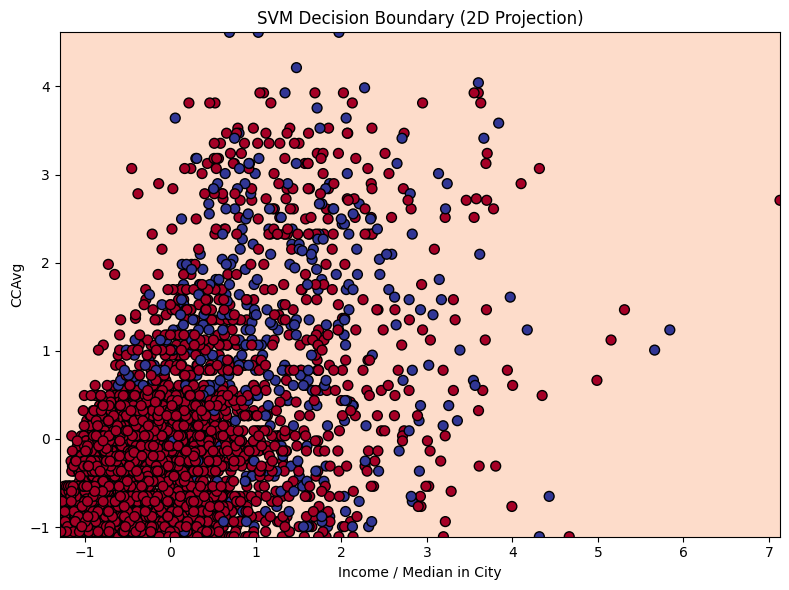

In [6]:
import numpy as np

# Pick Income/Median in city and CCAvg for visualization
X_2d = X_train[["Income / Median in city", "CCAvg"]]
y_2d = y_train

# Train 2D model
model_2d = SVC(kernel="rbf", C=10, gamma=0.1, probability=True)
model_2d.fit(X_2d.values, y_2d)

# Create decision boundary mesh
xx, yy = np.meshgrid(
    np.linspace(X_2d.iloc[:,0].min(), X_2d.iloc[:,0].max(), 100),
    np.linspace(X_2d.iloc[:,1].min(), X_2d.iloc[:,1].max(), 100)
)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
plt.scatter(X_2d.iloc[:,0], X_2d.iloc[:,1], c=y_2d, cmap="RdYlBu", edgecolors='black', s=50)
plt.xlabel("Income / Median in City")
plt.ylabel("CCAvg")
plt.title("SVM Decision Boundary (2D Projection)")
plt.tight_layout()
plt.show()